# A Multi-class classifier

In [1]:
import torch
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
# Generate data in blobs
RANDOM_SEED=42
NB_FEATURES=2
NB_BLOBS=4
X_set,y_set = make_blobs(n_samples=2000, n_features=NB_FEATURES, centers=NB_BLOBS, cluster_std=1.5, random_state=RANDOM_SEED)


tensor([[ 4.4471, -0.8496],
        [ 5.4521,  3.1119],
        [-8.9062, -8.8638],
        [-8.9192,  5.8501],
        [-5.8510,  6.0754]]) tensor([1, 1, 2, 3, 3])


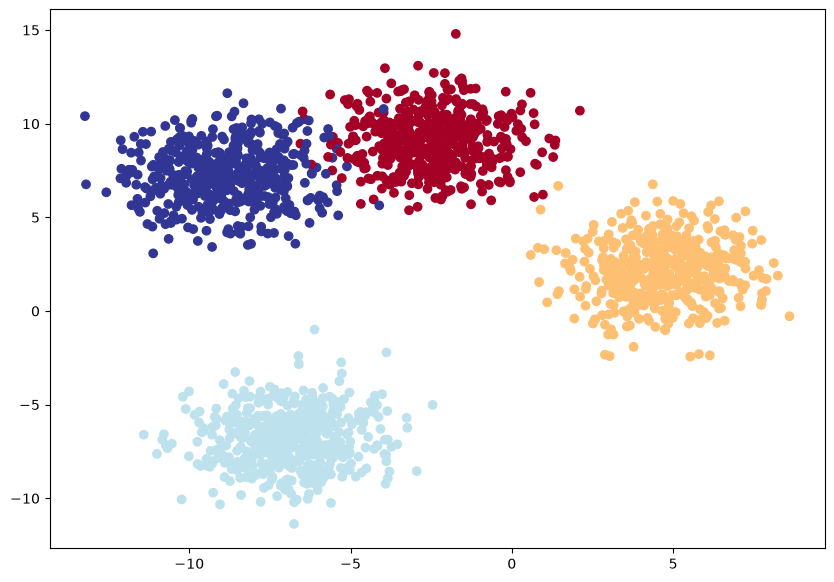

In [3]:
# transform as tensors
X = torch.from_numpy(X_set).type(torch.float)
y = torch.from_numpy(y_set).type(torch.LongTensor)
print(X[:5], y[:5])
# build train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED
)

# 4. Plot data
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu);

# Build the Neural Network


In [4]:
from torch import nn

device = torch.device("mps") if torch.backends.mps.is_available() else "cpu"

class BlobsClassifier(nn.Module):
    def __init__(self,input_features, output_features, hidden_units=8):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features),
            #nn.ReLU()
        )       
        
    def forward(self,x):
        return self.linear_layer_stack(x)
model=BlobsClassifier(input_features=NB_FEATURES,output_features=NB_BLOBS).to(device)
model

BlobsClassifier(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [5]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates if two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc

In [6]:
loss_fn=nn.CrossEntropyLoss()
optimizer= torch.optim.SGD(params=model.parameters(), lr=0.1)

In [7]:
# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [8]:
# One forward inference
model(X_train)[:5]
# model is predicting one value for each class that we have.

tensor([[ 0.5807, -0.5738,  0.9582,  1.4380],
        [-0.1409,  0.0635,  0.1925,  0.8970],
        [ 0.5332, -0.5373,  0.8969,  1.3586],
        [ 0.5344, -0.5671,  1.0085,  1.4277],
        [ 0.3651, -0.4881,  0.9858,  1.2638]], device='mps:0',
       grad_fn=<SliceBackward0>)

In [9]:
# To move to a class label, we need to map those 4 number per input to a probability to part of the matching class
# The softmax function calculates the probability of each prediction class being the actual predicted 
# class compared to all other possible classes.
y_logits = model(X_test)

# Perform softmax calculation on logits across dimension 1 to get prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1) 
print(y_logits[:5])
print(y_pred_probs[:5])
# the sum for each element is close to 1
print(torch.sum(y_pred_probs[0]))
# These prediction probablities are essentially saying how much the model thinks the target X sample 
# (the input) maps to each class.

# Which class does the model think is *most* likely at the index 0 sample?
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))

tensor([[ 0.5143, -0.6577,  1.3879,  1.6414],
        [ 0.1704,  0.1188,  0.3835,  0.7549],
        [ 0.5118, -0.5398,  0.9418,  1.3669],
        [ 0.1715, -0.0577,  0.4461,  0.7540],
        [ 0.3931, -0.4363,  0.7422,  1.1399]], device='mps:0',
       grad_fn=<SliceBackward0>)
tensor([[0.1472, 0.0456, 0.3527, 0.4545],
        [0.2008, 0.1907, 0.2484, 0.3602],
        [0.1909, 0.0667, 0.2935, 0.4489],
        [0.2040, 0.1622, 0.2685, 0.3653],
        [0.2014, 0.0879, 0.2856, 0.4251]], device='mps:0',
       grad_fn=<SliceBackward0>)
tensor(1.0000, device='mps:0', grad_fn=<SumBackward0>)
tensor([0.1472, 0.0456, 0.3527, 0.4545], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor(3, device='mps:0')


In [10]:
# Train the model and assess on test data
torch.manual_seed(RANDOM_SEED)
epochs=1000


for epoch in range(epochs):
    model.train()
    # 1. Forward pass
    y_logits = model(X_train).squeeze()
    # from logits -> prediction probabilities -> prediction labels
    y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)
    loss = loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # Testing
    model.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model(X_test).squeeze() 
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print out what's happening every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}")

Epoch: 0 | Loss: 1.43113, Accuracy: 25.12% | Test loss: 1.32871, Test acc: 24.50
Epoch: 10 | Loss: 0.85037, Accuracy: 63.44% | Test loss: 0.83479, Test acc: 78.25
Epoch: 20 | Loss: 0.53984, Accuracy: 98.06% | Test loss: 0.54359, Test acc: 98.25
Epoch: 30 | Loss: 0.27335, Accuracy: 98.69% | Test loss: 0.26433, Test acc: 99.50
Epoch: 40 | Loss: 0.10978, Accuracy: 98.75% | Test loss: 0.10452, Test acc: 99.50
Epoch: 50 | Loss: 0.06977, Accuracy: 98.81% | Test loss: 0.06619, Test acc: 99.50
Epoch: 60 | Loss: 0.05506, Accuracy: 98.81% | Test loss: 0.05145, Test acc: 99.50
Epoch: 70 | Loss: 0.04761, Accuracy: 98.81% | Test loss: 0.04369, Test acc: 99.50
Epoch: 80 | Loss: 0.04323, Accuracy: 98.81% | Test loss: 0.03891, Test acc: 99.50
Epoch: 90 | Loss: 0.04038, Accuracy: 98.81% | Test loss: 0.03567, Test acc: 99.50
Epoch: 100 | Loss: 0.03839, Accuracy: 98.81% | Test loss: 0.03333, Test acc: 99.50


Epoch: 110 | Loss: 0.03694, Accuracy: 98.88% | Test loss: 0.03157, Test acc: 99.50
Epoch: 120 | Loss: 0.03584, Accuracy: 98.88% | Test loss: 0.03018, Test acc: 99.50
Epoch: 130 | Loss: 0.03498, Accuracy: 98.88% | Test loss: 0.02907, Test acc: 99.50
Epoch: 140 | Loss: 0.03429, Accuracy: 98.88% | Test loss: 0.02815, Test acc: 99.50
Epoch: 150 | Loss: 0.03372, Accuracy: 98.88% | Test loss: 0.02739, Test acc: 99.50


Epoch: 160 | Loss: 0.03324, Accuracy: 98.88% | Test loss: 0.02675, Test acc: 99.50
Epoch: 170 | Loss: 0.03284, Accuracy: 98.88% | Test loss: 0.02619, Test acc: 99.50
Epoch: 180 | Loss: 0.03249, Accuracy: 98.94% | Test loss: 0.02569, Test acc: 99.50
Epoch: 190 | Loss: 0.03219, Accuracy: 98.94% | Test loss: 0.02525, Test acc: 99.50
Epoch: 200 | Loss: 0.03193, Accuracy: 98.94% | Test loss: 0.02487, Test acc: 99.50
Epoch: 210 | Loss: 0.03170, Accuracy: 98.94% | Test loss: 0.02452, Test acc: 99.50
Epoch: 220 | Loss: 0.03150, Accuracy: 98.94% | Test loss: 0.02421, Test acc: 99.50
Epoch: 230 | Loss: 0.03131, Accuracy: 98.94% | Test loss: 0.02393, Test acc: 99.50
Epoch: 240 | Loss: 0.03115, Accuracy: 98.94% | Test loss: 0.02367, Test acc: 99.50
Epoch: 250 | Loss: 0.03100, Accuracy: 98.94% | Test loss: 0.02344, Test acc: 99.50
Epoch: 260 | Loss: 0.03086, Accuracy: 98.94% | Test loss: 0.02323, Test acc: 99.50
Epoch: 270 | Loss: 0.03073, Accuracy: 98.94% | Test loss: 0.02303, Test acc: 99.50


Epoch: 280 | Loss: 0.03061, Accuracy: 98.94% | Test loss: 0.02285, Test acc: 99.50
Epoch: 290 | Loss: 0.03049, Accuracy: 98.94% | Test loss: 0.02268, Test acc: 99.50
Epoch: 300 | Loss: 0.03039, Accuracy: 98.94% | Test loss: 0.02252, Test acc: 99.50
Epoch: 310 | Loss: 0.03029, Accuracy: 98.94% | Test loss: 0.02237, Test acc: 99.50
Epoch: 320 | Loss: 0.03020, Accuracy: 98.94% | Test loss: 0.02223, Test acc: 99.50


Epoch: 330 | Loss: 0.03011, Accuracy: 98.94% | Test loss: 0.02210, Test acc: 99.50
Epoch: 340 | Loss: 0.03003, Accuracy: 98.94% | Test loss: 0.02198, Test acc: 99.50
Epoch: 350 | Loss: 0.02995, Accuracy: 98.94% | Test loss: 0.02186, Test acc: 99.50
Epoch: 360 | Loss: 0.02987, Accuracy: 99.00% | Test loss: 0.02175, Test acc: 99.50
Epoch: 370 | Loss: 0.02980, Accuracy: 99.00% | Test loss: 0.02165, Test acc: 99.50
Epoch: 380 | Loss: 0.02973, Accuracy: 99.00% | Test loss: 0.02154, Test acc: 99.50
Epoch: 390 | Loss: 0.02967, Accuracy: 99.00% | Test loss: 0.02145, Test acc: 99.50
Epoch: 400 | Loss: 0.02960, Accuracy: 99.00% | Test loss: 0.02136, Test acc: 99.50
Epoch: 410 | Loss: 0.02954, Accuracy: 99.00% | Test loss: 0.02127, Test acc: 99.50
Epoch: 420 | Loss: 0.02948, Accuracy: 99.00% | Test loss: 0.02118, Test acc: 99.50
Epoch: 430 | Loss: 0.02942, Accuracy: 99.00% | Test loss: 0.02110, Test acc: 99.50
Epoch: 440 | Loss: 0.02937, Accuracy: 99.00% | Test loss: 0.02102, Test acc: 99.50


...

Epoch: 620 | Loss: 0.02857, Accuracy: 99.06% | Test loss: 0.01993, Test acc: 99.50
Epoch: 630 | Loss: 0.02854, Accuracy: 99.06% | Test loss: 0.01988, Test acc: 99.50
Epoch: 640 | Loss: 0.02850, Accuracy: 99.06% | Test loss: 0.01983, Test acc: 99.50
Epoch: 650 | Loss: 0.02847, Accuracy: 99.06% | Test loss: 0.01978, Test acc: 99.50
Epoch: 660 | Loss: 0.02843, Accuracy: 99.06% | Test loss: 0.01974, Test acc: 99.50


Epoch: 670 | Loss: 0.02840, Accuracy: 99.06% | Test loss: 0.01969, Test acc: 99.50
Epoch: 680 | Loss: 0.02836, Accuracy: 99.06% | Test loss: 0.01965, Test acc: 99.50
Epoch: 690 | Loss: 0.02833, Accuracy: 99.06% | Test loss: 0.01961, Test acc: 99.50
Epoch: 700 | Loss: 0.02830, Accuracy: 99.06% | Test loss: 0.01956, Test acc: 99.50
Epoch: 710 | Loss: 0.02827, Accuracy: 99.06% | Test loss: 0.01952, Test acc: 99.50
Epoch: 720 | Loss: 0.02824, Accuracy: 99.06% | Test loss: 0.01948, Test acc: 99.50
Epoch: 730 | Loss: 0.02821, Accuracy: 99.06% | Test loss: 0.01944, Test acc: 99.50
Epoch: 740 | Loss: 0.02818, Accuracy: 99.06% | Test loss: 0.01940, Test acc: 99.50
Epoch: 750 | Loss: 0.02815, Accuracy: 99.06% | Test loss: 0.01936, Test acc: 99.50
Epoch: 760 | Loss: 0.02812, Accuracy: 99.06% | Test loss: 0.01932, Test acc: 99.50
Epoch: 770 | Loss: 0.02809, Accuracy: 99.06% | Test loss: 0.01928, Test acc: 99.50
Epoch: 780 | Loss: 0.02806, Accuracy: 99.06% | Test loss: 0.01924, Test acc: 99.50


Epoch: 790 | Loss: 0.02803, Accuracy: 99.06% | Test loss: 0.01920, Test acc: 99.50
Epoch: 800 | Loss: 0.02800, Accuracy: 99.06% | Test loss: 0.01916, Test acc: 99.50
Epoch: 810 | Loss: 0.02797, Accuracy: 99.06% | Test loss: 0.01912, Test acc: 99.50
Epoch: 820 | Loss: 0.02794, Accuracy: 99.06% | Test loss: 0.01909, Test acc: 99.50
Epoch: 830 | Loss: 0.02792, Accuracy: 99.06% | Test loss: 0.01905, Test acc: 99.50


Epoch: 840 | Loss: 0.02789, Accuracy: 99.06% | Test loss: 0.01901, Test acc: 99.50
Epoch: 850 | Loss: 0.02786, Accuracy: 99.06% | Test loss: 0.01898, Test acc: 99.50
Epoch: 860 | Loss: 0.02784, Accuracy: 99.06% | Test loss: 0.01894, Test acc: 99.50
Epoch: 870 | Loss: 0.02781, Accuracy: 99.06% | Test loss: 0.01890, Test acc: 99.50
Epoch: 880 | Loss: 0.02779, Accuracy: 99.06% | Test loss: 0.01887, Test acc: 99.50
Epoch: 890 | Loss: 0.02776, Accuracy: 99.06% | Test loss: 0.01883, Test acc: 99.50
Epoch: 900 | Loss: 0.02773, Accuracy: 99.06% | Test loss: 0.01880, Test acc: 99.50
Epoch: 910 | Loss: 0.02771, Accuracy: 99.06% | Test loss: 0.01876, Test acc: 99.50
Epoch: 920 | Loss: 0.02768, Accuracy: 99.06% | Test loss: 0.01873, Test acc: 99.50
Epoch: 930 | Loss: 0.02766, Accuracy: 99.06% | Test loss: 0.01869, Test acc: 99.50
Epoch: 940 | Loss: 0.02764, Accuracy: 99.06% | Test loss: 0.01866, Test acc: 99.50


Epoch: 950 | Loss: 0.02761, Accuracy: 99.06% | Test loss: 0.01863, Test acc: 99.50
Epoch: 960 | Loss: 0.02759, Accuracy: 99.06% | Test loss: 0.01860, Test acc: 99.50
Epoch: 970 | Loss: 0.02756, Accuracy: 99.06% | Test loss: 0.01856, Test acc: 99.50
Epoch: 980 | Loss: 0.02754, Accuracy: 99.06% | Test loss: 0.01853, Test acc: 99.50
Epoch: 990 | Loss: 0.02752, Accuracy: 99.06% | Test loss: 0.01850, Test acc: 99.50


In [11]:
model.eval()
with torch.inference_mode():
    y_logits = model(X_test)
    y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)
print(f"Predictions: {y_preds[:10]}\nLabels: {y_test[:10]}")
print(f"Test accuracy: {accuracy_fn(y_true=y_test, y_pred=y_preds)}%")

Predictions: tensor([0, 2, 3, 2, 3, 3, 1, 1, 3, 0], device='mps:0')
Labels: tensor([0, 2, 3, 2, 3, 3, 1, 1, 3, 0], device='mps:0')
Test accuracy: 99.5%


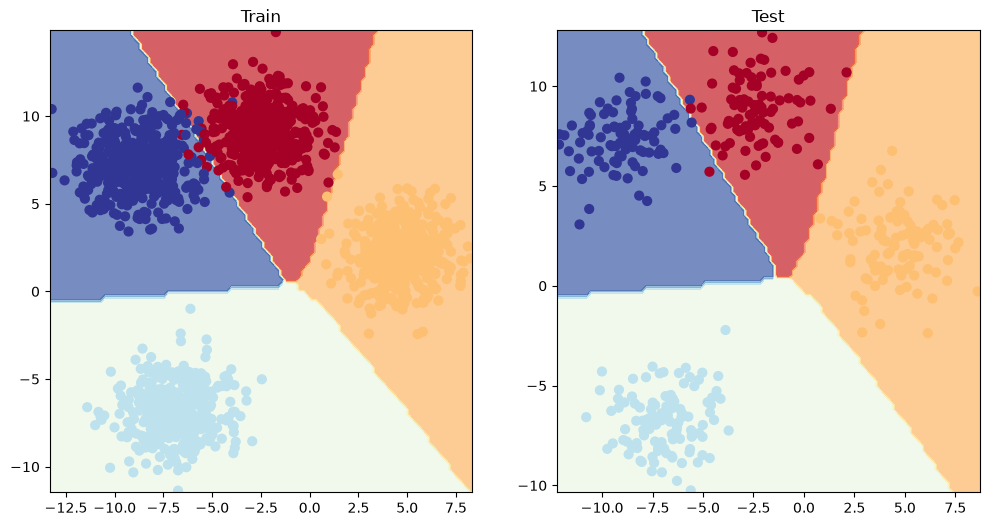

In [12]:
from helper_functions import plot_predictions, plot_decision_boundary
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)